# Team
- Stefanos Panteli UC1065916<br>
spante01@ucy.ac.cy

- Evangelia Krigkou UC1067400<br>
ekrigk01@ucy.ac.cy

- Rafael Chrysanthou UC1064747<br>
rchrys03@ucy.ac.cy

- Kyprianos Erakleous
kerakl02@ucy.ac.cy UC1058854<br>


GitHub: [https://github.com/stefanosPanteli/EPL445](https://github.com/stefanosPanteli/EPL445)

# Installs

In [1]:
#!pip install opencv-python matplotlib numpy

# Imports

In [ ]:
from sklearn.metrics import confusion_matrix as sk_confusion_matrix, ConfusionMatrixDisplay
import cv2
from torch.utils.data import Dataset, DataLoader
import torch
from torchvision import transforms
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import pandas as pd
import numpy as np
import os
from pathlib import Path
from typing import Callable, Union, Any, List, Dict, Tuple, Optional, Literal

if not os.path.exists('cat-21'):
    os.mkdir('cat-21')

if not os.path.exists('cat-21/training'):
    os.mkdir('cat-21/training')
if not os.path.exists('cat-21/validation'):
    os.mkdir('cat-21/validation')

# Contants & Globals

In [2]:
UNDERLINE = '\033[4m'
BOLD = '\033[1m'
CYAN = '\033[36m'
WHITE = '\033[37m'
RESET = '\033[0m'
def nicely_print(title: str, content: str= '') -> None:
    '''
    `nicely_print` prints a title and content in a nice format.

    `Args:`
        title (str): The title of the section. Will be Underlined, Bold, Cyan.
        content (str): The content of the section. Will be Bold, White.
    '''
    print(f'{UNDERLINE}{BOLD}{CYAN}{title}{RESET}', end=' ')
    print(f'{BOLD}{WHITE}{content}{RESET}\n')

label_to_int = {
    'not_initialized': 0,
    'incision': 1,
    'viscoelasticum': 2,
    'rhexis': 3,
    'hydrodissektion': 4,
    'phako': 5,
    'irrigation-aspiration': 6,
    'kapselpolishing': 7,
    'linsenimplantation': 8,
    'visco-absaugung': 9,
    'tonisieren': 10,
    'antibiotikum': 11
}

phase_order = [label.lower() for label in label_to_int.keys()]

phase_to_color = {
    label: plt.get_cmap("tab20")(i % plt.get_cmap("tab20").N)
    for i, label in enumerate(phase_order)
}

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Getting to Know the Dataset

## Init Data

In [3]:
def load_case_annotations(csv_path: Path) -> Dict[int, int | str]:
    '''
    `load_case_annotations` loads the annotations for a single case.
        Reads the CSV file and returns a dictionary {frame_number: label}.

    `Args:`
        csv_path (Path): The path to the CSV file.

    `Returns:`
        Dict[int, int | str]: A dictionary of annotations.
    '''
    df = pd.read_csv(csv_path, names= ['frame_no', 'label'])
    return {
        int(frame): label
        for frame, label in zip(df['frame_no'], df['label'])
    }


def build_cases_dict(root_dir: str) -> Dict[str, Dict[int, Dict]]:
    '''
    `build_cases_dict` builds a dictionary for every case in the dataset.

    `Args:`
        root_dir (str): The root directory of the dataset.

    `Returns:`
        Dict[str, Dict[int, Dict]]: A dictionary of cases.
        * Format: { 'train/val': { case_id: { 'video_path': str, 'annotations': Dict }
    '''
    root = Path(root_dir)

    cases = {
        'train': {},
        'val': {}
    }

    split_map = {
        'training': 'train',
        'validation': 'val'
    }

    for folder_name, split_name in split_map.items():
        split_dir = root / folder_name

        if not split_dir.exists():
            print(f'Warning: folder not found -> {split_dir}')
            continue

        for video_path in sorted(split_dir.glob('case_*.mp4')):
            case_name = video_path.stem # Removes .mp4
            csv_path = split_dir / f'{case_name}.csv'

            if not csv_path.exists():
                print(f'Warning: missing CSV for {video_path.name}')
                continue

            try:
                case_id = int(case_name.split("_")[1])
            except (IndexError, ValueError):
                print(f'Warning: could not parse case id from {video_path.name}')
                continue

            annotations = load_case_annotations(csv_path)

            cases[split_name][case_id] = {
                'video_path': str(video_path),
                'annotations': annotations
            }

    return cases

nicely_print('Fetching', 'Video Paths & Annotations')
cases = build_cases_dict('cat-21')
annotations_only = {
    case_id: case_info['annotations']
    for case_id, case_info in cases['train'].items()
}

if cases['train'] == {}:
    print('No train videos provided')
if cases['val'] == {}:
    print('No validation videos provided')

if cases['train'] != {} and cases['val'] != {}:
    for split, cases_dict in cases.items():
        print(f'Split: {split}')
        for case_id, case_info in cases_dict.items():
            last_label = ''
            print(f'  Case ID: {case_id}')
            print(f'  - Video Path: {case_info["video_path"]}')
            print(f'  - Annotations:')
            for frame, label in case_info['annotations'].items():
                if label == last_label: continue
                print(f'      {frame:>5} - {label}')
                last_label = label
            print()
        print()


Fetching Video Paths & Annotations

Split: train
  Case ID: 1
  - Video Path: cat-21/training/case_01.mp4
  - Annotations:
          0 - not_initialized
         68 - Incision
       1043 - Viscoelasticum
       1228 - Rhexis
       2118 - Hydrodissektion
       3478 - Phako
       6864 - Irrigation-Aspiration
       7727 - Kapselpolishing
       8473 - Viscoelasticum
       8683 - Linsenimplantation
       9482 - Visco-Absaugung
      14138 - Tonisieren
      14623 - Antibiotikum

  Case ID: 2
  - Video Path: cat-21/training/case_02.mp4
  - Annotations:
          0 - not_initialized
         20 - Incision
        357 - Viscoelasticum
        572 - Rhexis
       1030 - Hydrodissektion
       1432 - Phako
       3032 - Irrigation-Aspiration
       3963 - Kapselpolishing
       4330 - Viscoelasticum
       4495 - Linsenimplantation
       4853 - Visco-Absaugung
       5867 - Tonisieren
       6167 - Antibiotikum

  Case ID: 3
  - Video Path: cat-21/training/case_03.mp4
  - Annotations:
 

## Plot Statistics

Frame Annotations by Case 



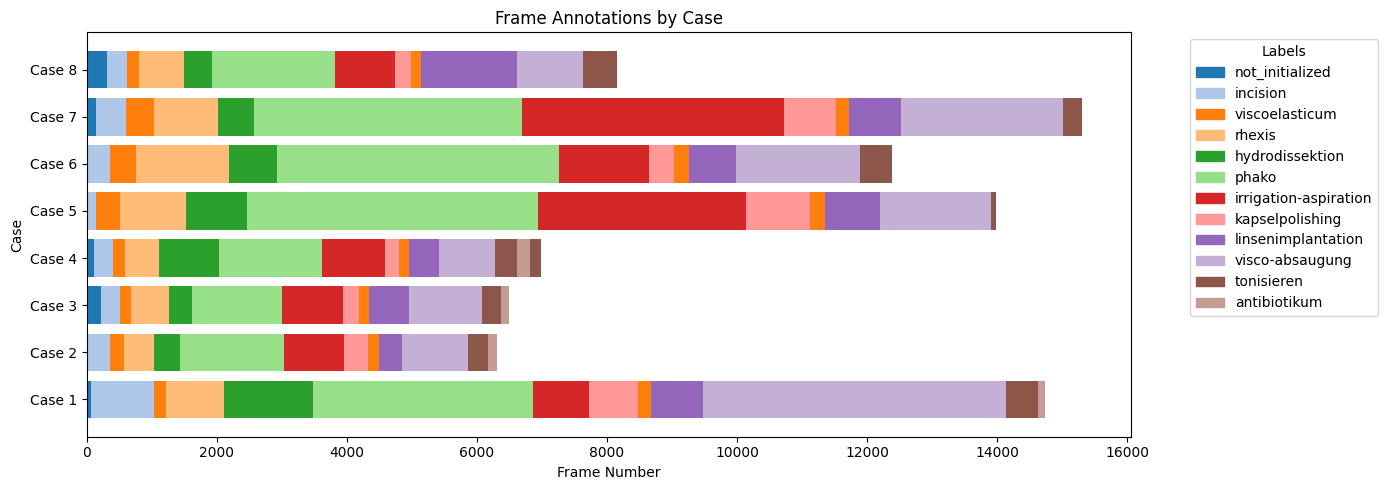

In [4]:
def plot_frame_labels(annotations: Dict[int, Dict[int, str]]) -> None:
    '''
    `plot_frame_labels` plots a bar for each case, and a colour represents a label

    `Args:`
        annotations (Dict[int, Dict[int, str]]): A dictionary of the frame annotations.
        * Format: { case_id: { frame_number: label } }
    '''
    if not annotations:
        print('No annotations to plot.')
        return

    # Get all unique labels
    all_labels = label_to_int.keys()

    # Sort case ids for cleaner plotting
    case_ids = sorted(annotations.keys())

    plt.figure(figsize= (14, max(5, len(case_ids) * 0.5)))

    for y, case_id in enumerate(case_ids):
        frame_dict = annotations[case_id]

        if not frame_dict:
            continue

        # Sort frames
        sorted_items = sorted(frame_dict.items())   # [(frame_no, label), ...]
        frames = [item[0] for item in sorted_items]
        labels = [item[1] for item in sorted_items]

        # Merge consecutive frames with the same label into one segment
        start_frame = frames[0]
        current_label = labels[0].lower()
        prev_frame = frames[0]

        for i in range(1, len(frames)):
            frame: int = frames[i]
            label: str = labels[i].lower()

            # End current segment if label changes or frames are not consecutive
            if label != current_label or frame != prev_frame + 1:
                width = prev_frame - start_frame + 1
                plt.barh(
                    y= y, width= width, left= start_frame, height= 0.8,
                    color= phase_to_color[current_label]
                )
                start_frame = frame
                current_label = label

            prev_frame = frame

        # Plot the last segment
        width = prev_frame - start_frame + 1
        plt.barh(
            y= y, width= width, left= start_frame, height= 0.8,
            color= phase_to_color[current_label]
        )

    # Axis labels and title
    plt.yticks(range(len(case_ids)), [f'Case {case_id}' for case_id in case_ids])
    plt.xlabel('Frame Number')
    plt.ylabel('Case')
    plt.title('Frame Annotations by Case')

    # Legend
    legend_patches = [
        mpatches.Patch(color= phase_to_color[label], label= label)
        for label in all_labels
    ]
    plt.legend(handles= legend_patches, title= 'Labels', bbox_to_anchor= (1.05, 1), loc= 'upper left')

    plt.tight_layout()
    plt.show()

nicely_print('Frame Annotations by Case')
plot_frame_labels(annotations_only)

Average Phase Percentage per Case with Distribution 



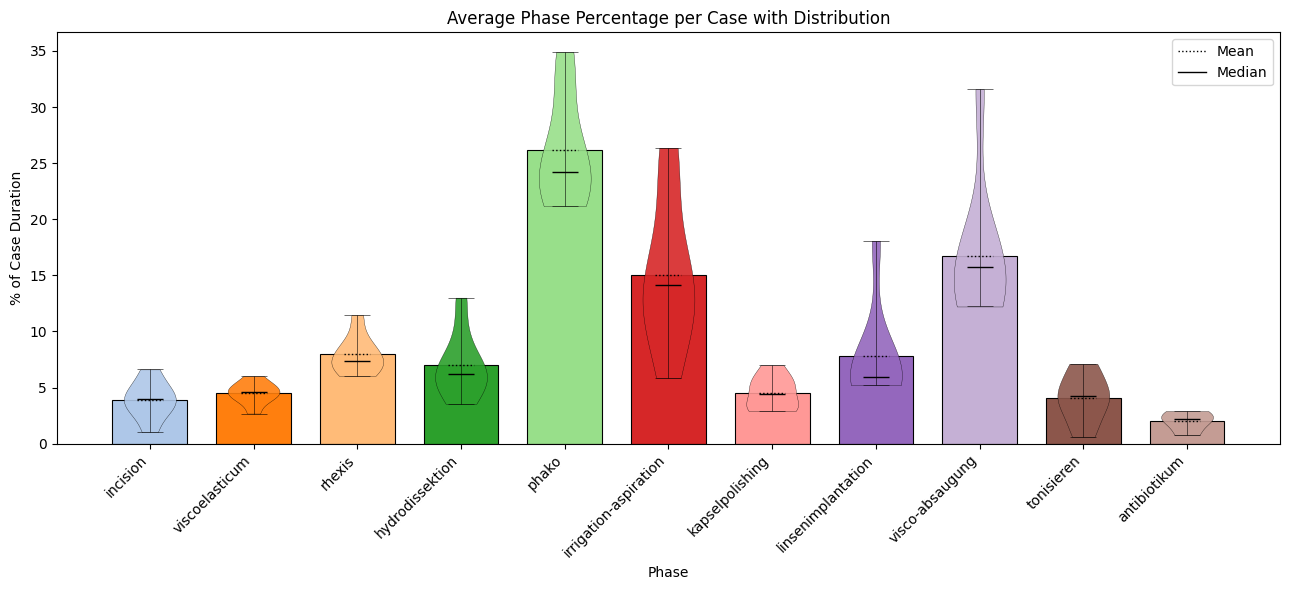

In [6]:
def plot_phase_percentage_summary_and_distribution(annotations: Dict[int, Dict[int, str]]) -> pd.DataFrame:
    '''
    `plot_frame_labels` plots a bar for each case, and a colour represents a label

    `Args:`
        annotations (Dict[int, Dict[int, str]]): A dictionary of the frame annotations.
        * Format: { case_id: { frame_number: label } }

    `Returns:`
        pd.DataFrame: A dataframe with the percentage of total case duration occupied by each phase.
        * Columns: case_id, label, percentage
    '''
    if not annotations:
        print('No annotations to plot.')
        return pd.DataFrame(columns= ['case_id', 'label', 'percentage'])

    rows = []

    for case_id, frame_dict in annotations.items():
        if not frame_dict:
            continue

        sorted_items = sorted((int(frame), str(label).lower()) for frame, label in frame_dict.items())
        frames = [frame for frame, _ in sorted_items]
        labels = [label for _, label in sorted_items]

        case_total = frames[-1] - frames[0] + 1

        label_counts = {}
        for label in labels:
            label_counts[label] = label_counts.get(label, 0) + 1

        for label, count in label_counts.items():
            if label == 'not_initialized':
                continue

            rows.append({
                'case_id': case_id,
                'label': label,
                'percentage': count / case_total * 100
            })

    percentage_df = pd.DataFrame(rows)

    if percentage_df.empty:
        print('No valid phase percentages to plot.')
        return pd.DataFrame(columns= ['case_id', 'label', 'percentage'])

    label_order = [label.lower() for label in label_to_int.keys() if label.lower() != 'not_initialized']

    plot_df = percentage_df.copy()
    plot_df['label'] = plot_df['label'].astype(str).str.lower()
    plot_df = plot_df[plot_df['label'].isin(label_order)].copy()

    summary_df = (
        plot_df
        .groupby('label', as_index= False)['percentage']
        .mean()
    )
    summary_df['label'] = pd.Categorical(summary_df['label'], categories= label_order, ordered= True)
    summary_df = summary_df.sort_values('label').reset_index(drop= True)

    grouped_data = [
        plot_df.loc[plot_df['label'] == label, 'percentage'].values
        for label in label_order
        if not plot_df.loc[plot_df['label'] == label, 'percentage'].empty
    ]
    plotted_labels = [
        label for label in label_order
        if not plot_df.loc[plot_df['label'] == label, 'percentage'].empty
    ]

    summary_plot_df = summary_df[summary_df['label'].astype(str).isin(plotted_labels)].copy()
    summary_plot_df['label'] = summary_plot_df['label'].astype(str)

    x_positions = list(range(len(plotted_labels)))

    plt.figure(figsize= (13, 6))

    plt.bar(
        x_positions,
        summary_plot_df['percentage'],
        color= [phase_to_color[label] for label in summary_plot_df['label']],
        width= 0.72,
        edgecolor= 'black',
        linewidth= 0.8
    )

    violin_parts = plt.violinplot(
        dataset= grouped_data,
        positions= x_positions,
        widths= 0.5,
        showmeans= True,
        showmedians= True
    )

    for body, label in zip(violin_parts['bodies'], plotted_labels):
        body.set_facecolor(phase_to_color[label])
        body.set_edgecolor('black')
        body.set_alpha(0.9)
        body.set_linewidth(0.25)

    if 'cmeans' in violin_parts:
        violin_parts['cmeans'].set_color('black')
        violin_parts['cmeans'].set_linestyle(':')
        violin_parts['cmeans'].set_linewidth(1.0)

    if 'cmedians' in violin_parts:
        violin_parts['cmedians'].set_color('black')
        violin_parts['cmedians'].set_linestyle('-')
        violin_parts['cmedians'].set_linewidth(1.0)

    if 'cbars' in violin_parts:
        violin_parts['cbars'].set_color('black')
        violin_parts['cbars'].set_linewidth(0.4)

    if 'cmins' in violin_parts:
        violin_parts['cmins'].set_color('black')
        violin_parts['cmins'].set_linewidth(0.4)

    if 'cmaxes' in violin_parts:
        violin_parts['cmaxes'].set_color('black')
        violin_parts['cmaxes'].set_linewidth(0.4)

    mean_handle = plt.Line2D([0], [0], color= 'black', linestyle= ':', linewidth= 1.0, label= 'Mean')
    median_handle = plt.Line2D([0], [0], color= 'black', linestyle= '-', linewidth= 1.0, label= 'Median')

    plt.legend(handles= [mean_handle, median_handle], loc= 'upper right')
    plt.xticks(ticks= x_positions, labels= plotted_labels, rotation= 45, ha= 'right')
    plt.xlabel('Phase')
    plt.ylabel('% of Case Duration')
    plt.title('Average Phase Percentage per Case with Distribution')
    plt.tight_layout()
    plt.show()

    return percentage_df

nicely_print('Average Phase Percentage per Case with Distribution')
phase_percentage_df = plot_phase_percentage_summary_and_distribution(annotations= annotations_only)

In [7]:
def plot_phase_start_position(annotations: Dict[int, Dict[int, str]]) -> pd.DataFrame:
    '''
    `plot_frame_labels` plots a bar for each case, and a colour represents a label

    `Args:`
        annotations (Dict[int, Dict[int, str]]): A dictionary of the frame annotations.
        * Format: { case_id: { frame_number: label } }

    `Returns:`
        pd.DataFrame: A dataframe with the start percentage of each phase per case, plus summary statistics.
        * Columns: label, mean_start_percentage, median_start_percentage, std_start_percentage
    '''
    if not annotations:
        print('No annotations to plot.')
        return pd.DataFrame(columns= ['label', 'mean_start_percentage', 'median_start_percentage', 'std_start_percentage'])

    rows = []

    for case_id, frame_dict in annotations.items():
        if not frame_dict:
            continue

        sorted_items = sorted((int(frame), str(label).lower()) for frame, label in frame_dict.items())
        frames = [frame for frame, _ in sorted_items]

        case_start = frames[0]
        case_end = frames[-1]
        case_total = case_end - case_start + 1

        seen_labels = set()

        for frame, label in sorted_items:
            if label == 'not_initialized' or label in seen_labels:
                continue

            start_percentage = (frame - case_start) / case_total * 100
            rows.append({
                'case_id': case_id,
                'label': label,
                'start_percentage': start_percentage
            })
            seen_labels.add(label)

    start_df = pd.DataFrame(rows)

    if start_df.empty:
        print('No valid phase start positions to plot.')
        return pd.DataFrame(columns= ['label', 'mean_start_percentage', 'median_start_percentage', 'std_start_percentage'])

    label_order = [label.lower() for label in label_to_int.keys() if label.lower() != 'not_initialized']

    summary_df = (
        start_df
        .groupby('label', as_index= False)
        .agg(
            mean_start_percentage= ('start_percentage', 'mean'),
            median_start_percentage= ('start_percentage', 'median'),
            std_start_percentage= ('start_percentage', 'std')
        )
    )

    summary_df['label'] = pd.Categorical(summary_df['label'], categories= label_order, ordered= True)
    summary_df = summary_df.sort_values('label').reset_index(drop= True)

    plt.figure(figsize= (13, 6))
    plt.bar(
        summary_df['label'].astype(str),
        summary_df['mean_start_percentage'],
        color= [phase_to_color[label] for label in summary_df['label'].astype(str)],
        edgecolor= 'black',
        linewidth= 0.8
    )

    plt.errorbar(
        x= range(len(summary_df)),
        y= summary_df['mean_start_percentage'],
        yerr= summary_df['std_start_percentage'].fillna(0),
        fmt= 'none',
        ecolor= 'black',
        elinewidth= 1.0,
        capsize= 4
    )

    plt.xlabel('Phase')
    plt.ylabel('Average Start Position (% of Case)')
    plt.title('Average Phase Start Position')
    plt.xticks(ticks= range(len(summary_df)), labels= summary_df['label'].astype(str), rotation= 45, ha= 'right')
    plt.tight_layout()
    plt.show()

    return summary_df

nicely_print('Average Phase Start Position')
phase_start_position_df = plot_phase_start_position(annotations= annotations_only)

Average Phase Start Position 



KeyboardInterrupt: 

In [ ]:
def show_middle_frame_of_each_phase(case_info: Dict[str, object], case_id: int) -> pd.DataFrame:
    '''
    `plot_frame_labels` plots a bar for each case, and a colour represents a label

    `Args:`
        case_info (Dict[str, object]): A dictionary containing the video path and frame annotations for one case.
        * Format: { 'video_path': str, 'annotations': { frame_number: label } }

        case_id (int): The case identifier.
        * Format: integer case id

    `Returns:`
        pd.DataFrame: A dataframe with the selected middle frame and image metrics for each phase.
        * Columns: case_id, phase, start_frame, end_frame, middle_frame, height, width, channels, dtype, mean_b, mean_g, mean_r, mean_gray, std_gray
    '''
    if 'video_path' not in case_info or 'annotations' not in case_info:
        raise ValueError('case_info must contain \'video_path\' and \'annotations\'.')

    video_path = case_info['video_path']
    annotations = case_info['annotations']

    if not annotations:
        raise ValueError('This case has no annotations.')

    sorted_items = sorted((int(frame), str(label).lower()) for frame, label in annotations.items())
    frames = [frame for frame, _ in sorted_items]
    labels = [label for _, label in sorted_items]

    segments = []
    start_frame = frames[0]
    current_label = labels[0]
    prev_frame = frames[0]

    for i in range(1, len(frames)):
        frame = frames[i]
        label = labels[i]

        if label != current_label or frame != prev_frame + 1:
            segments.append({
                'label': current_label,
                'start_frame': start_frame,
                'end_frame': prev_frame
            })
            start_frame = frame
            current_label = label

        prev_frame = frame

    segments.append({
        'label': current_label,
        'start_frame': start_frame,
        'end_frame': prev_frame
    })

    selected_segments = []
    seen_labels = set()

    for segment in segments:
        label = segment['label']
        if label in seen_labels:
            continue

        middle_frame = (segment['start_frame'] + segment['end_frame']) // 2
        selected_segments.append({
            'label': label,
            'start_frame': segment['start_frame'],
            'end_frame': segment['end_frame'],
            'middle_frame': middle_frame
        })
        seen_labels.add(label)

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f'Could not open video: {video_path}')

    n_phases = len(selected_segments)
    n_cols = 3
    n_rows = int(np.ceil(n_phases / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize= (16, 4.5 * n_rows))
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = np.array([axes])
    elif n_cols == 1:
        axes = axes.reshape(-1, 1)

    metrics_rows = []

    for idx, segment in enumerate(selected_segments):
        row_idx = idx // n_cols
        col_idx = idx % n_cols
        ax = axes[row_idx, col_idx]

        middle_frame = segment['middle_frame']
        cap.set(cv2.CAP_PROP_POS_FRAMES, middle_frame)
        ok, frame_bgr = cap.read()

        if not ok or frame_bgr is None:
            ax.axis('off')
            ax.set_title(f'{segment["label"]}\nframe {middle_frame}\nread failed')
            continue

        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        frame_gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)

        height, width = frame_bgr.shape[:2]
        channels = frame_bgr.shape[2] if frame_bgr.ndim == 3 else 1

        mean_b = float(frame_bgr[:, :, 0].mean())
        mean_g = float(frame_bgr[:, :, 1].mean())
        mean_r = float(frame_bgr[:, :, 2].mean())
        mean_gray = float(frame_gray.mean())
        std_gray = float(frame_gray.std())

        metrics_rows.append({
            'case_id': case_id,
            'phase': segment['label'],
            'start_frame': segment['start_frame'],
            'end_frame': segment['end_frame'],
            'middle_frame': middle_frame,
            'height': height,
            'width': width,
            'channels': channels,
            'dtype': str(frame_bgr.dtype),
            'mean_b': mean_b,
            'mean_g': mean_g,
            'mean_r': mean_r,
            'mean_gray': mean_gray,
            'std_gray': std_gray
        })

        ax.imshow(frame_rgb)
        ax.set_title(f'{segment["label"]} (frame {middle_frame})')
        ax.axis('off')

    total_axes = n_rows * n_cols
    for idx in range(n_phases, total_axes):
        row_idx = idx // n_cols
        col_idx = idx % n_cols
        axes[row_idx, col_idx].axis('off')

    cap.release()
    plt.suptitle(f'Case {case_id}: Middle Frame of Each Phase', y= 1.02, fontsize= 14)
    plt.tight_layout()
    plt.show()

    metrics_df = pd.DataFrame(metrics_rows)

    if not metrics_df.empty:
        display(metrics_df)

    return metrics_df

nicely_print('Middle Frame of Each Phase')
first_case_id = sorted(cases['train'].keys())[0]
first_case_info = cases['train'][first_case_id]
first_case_metrics_df = show_middle_frame_of_each_phase(case_info= first_case_info, case_id= first_case_id)

In [ ]:
def get_per_phase_stats(case_info: Dict[str, object], case_id: int, frame_step: int= 15) -> pd.DataFrame:
    '''
    `plot_frame_labels` plots a bar for each case, and a colour represents a label

    `Args:`
        case_info (Dict[str, object]): A dictionary containing the video path and frame annotations for one case.
        * Format: { 'video_path': str, 'annotations': { frame_number: label }}
        case_id (int): The case identifier.
        frame_step (int): The step used to subsample frames.

    `Returns:`
        pd.DataFrame: A dataframe with visual statistics per phase.
        * Columns: case_id, phase, n_frames_used, mean_b, std_b, mean_g, std_g, mean_r, std_r,
                   mean_gray, std_gray, median_gray, sobel_mean, sobel_std, laplacian_var,
                   mean_saturation, std_saturation, median_saturation, mean_value, std_value,
                   median_value, edge_density
    '''
    video_path = case_info['video_path']
    annotations = case_info['annotations']

    if not annotations:
        return pd.DataFrame()

    total_frames = max(annotations.keys())

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f'Could not open video: {video_path}')

    phase_frames = {}

    for frame_idx, label in annotations.items():
        if frame_idx % frame_step != 0:
            continue

        label = str(label).lower()
        phase_frames.setdefault(label, []).append(int(frame_idx))

    results = []

    for phase, frame_indices in phase_frames.items():
        mean_b_list = []
        std_b_list = []
        mean_g_list = []
        std_g_list = []
        mean_r_list = []
        std_r_list = []
        mean_gray_list = []
        std_gray_list = []
        median_gray_list = []
        sobel_mean_list = []
        sobel_std_list = []
        laplacian_var_list = []
        mean_saturation_list = []
        std_saturation_list = []
        mean_value_list = []
        std_value_list = []
        edge_density_list = []

        n_frames_used = 0

        for i, frame_idx in enumerate(frame_indices):
            if i % 25 == 0:
                print(f'Processing frame {frame_idx}/{total_frames} (Phase: {phase})...'.ljust(90), end= '\r')

            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
            ok, frame = cap.read()
            if not ok or frame is None:
                continue

            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

            sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize= 3)
            sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize= 3)
            sobel_mag = np.sqrt(sobel_x ** 2 + sobel_y ** 2)

            laplacian = cv2.Laplacian(gray, cv2.CV_64F)
            edges = cv2.Canny(gray, 100, 200)

            b, g, r = cv2.split(frame)
            sat = hsv[:, :, 1]
            val = hsv[:, :, 2]

            mean_b_list.append(float(np.mean(b)))
            std_b_list.append(float(np.std(b)))

            mean_g_list.append(float(np.mean(g)))
            std_g_list.append(float(np.std(g)))

            mean_r_list.append(float(np.mean(r)))
            std_r_list.append(float(np.std(r)))

            mean_gray_list.append(float(np.mean(gray)))
            std_gray_list.append(float(np.std(gray)))
            median_gray_list.append(float(np.median(gray)))

            sobel_mean_list.append(float(np.mean(sobel_mag)))
            sobel_std_list.append(float(np.std(sobel_mag)))
            laplacian_var_list.append(float(np.var(laplacian)))

            mean_saturation_list.append(float(np.mean(sat)))
            std_saturation_list.append(float(np.std(sat)))

            mean_value_list.append(float(np.mean(val)))
            std_value_list.append(float(np.std(val)))

            edge_density_list.append(float(np.mean(edges > 0)))

            n_frames_used += 1

        print(f'Finished phase {phase}')

        if n_frames_used == 0:
            continue

        results.append({
            'case_id': case_id,
            'phase': phase,
            'n_frames_used': n_frames_used,

            'mean_b': float(np.mean(mean_b_list)),
            'std_b': float(np.mean(std_b_list)),
            'median_b': float(np.median(mean_b_list)),

            'mean_g': float(np.mean(mean_g_list)),
            'std_g': float(np.mean(std_g_list)),
            'median_g': float(np.median(mean_g_list)),

            'mean_r': float(np.mean(mean_r_list)),
            'std_r': float(np.mean(std_r_list)),
            'median_r': float(np.median(mean_r_list)),

            'mean_gray': float(np.mean(mean_gray_list)),
            'std_gray': float(np.mean(std_gray_list)),
            'median_gray': float(np.mean(median_gray_list)),

            'sobel_mean': float(np.mean(sobel_mean_list)),
            'sobel_std': float(np.mean(sobel_std_list)),
            'laplacian_var': float(np.mean(laplacian_var_list)),

            'mean_saturation': float(np.mean(mean_saturation_list)),
            'std_saturation': float(np.mean(std_saturation_list)),
            'median_saturation': float(np.median(mean_saturation_list)),

            'mean_value': float(np.mean(mean_value_list)),
            'std_value': float(np.mean(std_value_list)),
            'median_value': float(np.median(mean_value_list)),

            'edge_density': float(np.mean(edge_density_list))
        })

    cap.release()

    return pd.DataFrame(results)

nicely_print('Getting Phase Statistics')
phase_stats = get_per_phase_stats(case_info= first_case_info, case_id= first_case_id, frame_step= 25)

In [ ]:
def plot_phase_stats_overview(phase_stats_df: pd.DataFrame) -> None:
    '''
    `plot_frame_labels` plots a bar for each case, and a colour represents a label

    `Args:`
        phase_stats_df (pd.DataFrame): A dataframe with visual statistics per phase.
        * Columns: case_id, phase, n_frames_used, mean_b, std_b, median_b, mean_g, std_g, median_g,
                   mean_r, std_r, median_r, mean_gray, std_gray, median_gray, sobel_mean, sobel_std,
                   laplacian_var, mean_saturation, std_saturation, median_saturation, mean_value,
                   std_value, median_value, edge_density
    '''
    required_cols = {
        'phase',
        'mean_b', 'std_b',
        'mean_g', 'std_g',
        'mean_r', 'std_r',
        'mean_gray', 'std_gray',
        'sobel_mean', 'sobel_std',
        'laplacian_var',
        'mean_saturation', 'std_saturation',
        'mean_value', 'std_value',
        'edge_density'
    }

    if phase_stats_df.empty or not required_cols.issubset(phase_stats_df.columns):
        print('No valid phase stats dataframe to plot.')
        return

    label_order = [label.lower() for label in label_to_int.keys()]
    plot_df = phase_stats_df.copy()
    plot_df['phase'] = plot_df['phase'].astype(str).str.lower()
    plot_df = plot_df[plot_df['phase'].isin(label_order)].copy()

    if plot_df.empty:
        print('No valid phase stats dataframe to plot.')
        return

    plot_df['phase'] = pd.Categorical(plot_df['phase'], categories= label_order, ordered= True)
    plot_df = plot_df.sort_values('phase').reset_index(drop= True)

    x = np.arange(len(plot_df))
    x_labels = plot_df['phase'].astype(str).tolist()

    def add_phase_dividers(ax: plt.Axes) -> None:
        for xi in x[:-1]:
            ax.axvline(x= xi + 0.5, color= 'lightgray', linestyle= ':', linewidth= 0.8, zorder= 0)

    def draw_mean_std_connectors(
        ax: plt.Axes,
        x_shifted: np.ndarray,
        means: np.ndarray,
        stds: np.ndarray,
        color: str,
        half_width: float= 0.055,
        line_width: float= 0.85
    ) -> None:
        lower = means - stds
        upper = means + stds

        ax.vlines(
            x= x_shifted,
            ymin= lower,
            ymax= upper,
            color= color,
            linewidth= line_width,
            alpha= 0.9
        )
        ax.hlines(
            y= lower,
            xmin= x_shifted - half_width,
            xmax= x_shifted + half_width,
            color= color,
            linewidth= line_width
        )
        ax.hlines(
            y= upper,
            xmin= x_shifted - half_width,
            xmax= x_shifted + half_width,
            color= color,
            linewidth= line_width
        )

    plt.figure(figsize= (14, 6))
    ax = plt.gca()

    rgb_gray_specs = [
        ('mean_r', 'std_r', 'red', 'R', -0.18),
        ('mean_gray', 'std_gray', 'gray', 'Gray', -0.06),
        ('mean_g', 'std_g', 'green', 'G', 0.06),
        ('mean_b', 'std_b', 'blue', 'B', 0.18)
    ]

    add_phase_dividers(ax)

    for mean_col, std_col, color, label, offset in rgb_gray_specs:
        means = plot_df[mean_col].to_numpy()
        stds = plot_df[std_col].to_numpy()
        x_shifted = x + offset

        ax.plot(x_shifted, means, marker= 'o', color= color, linewidth= 1.2, markersize= 4, label= label)
        draw_mean_std_connectors(
            ax= ax,
            x_shifted= x_shifted,
            means= means,
            stds= stds,
            color= color,
            half_width= 0.055,
            line_width= 0.85
        )

    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation= 45, ha= 'right')
    ax.set_xlabel('Phase')
    ax.set_ylabel('Intensity')
    ax.set_title('RGB and Gray Statistics per Phase')
    ax.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize= (14, 6))
    ax = plt.gca()

    sv_specs = [
        ('mean_saturation', 'std_saturation', 'purple', 'Saturation', -0.08),
        ('mean_value', 'std_value', 'orange', 'Value', 0.08)
    ]

    add_phase_dividers(ax)

    for mean_col, std_col, color, label, offset in sv_specs:
        means = plot_df[mean_col].to_numpy()
        stds = plot_df[std_col].to_numpy()
        x_shifted = x + offset

        ax.plot(x_shifted, means, marker= 'o', color= color, linewidth= 1.2, markersize= 4, label= label)
        draw_mean_std_connectors(
            ax= ax,
            x_shifted= x_shifted,
            means= means,
            stds= stds,
            color= color,
            half_width= 0.055,
            line_width= 0.85
        )

    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation= 45, ha= 'right')
    ax.set_xlabel('Phase')
    ax.set_ylabel('HSV Statistic')
    ax.set_title('Saturation and Value per Phase')
    ax.legend()
    plt.tight_layout()
    plt.show()

    fig, ax1 = plt.subplots(figsize= (14, 6))

    add_phase_dividers(ax1)

    ax1.plot(
        x,
        plot_df['laplacian_var'],
        marker= 'o',
        color= 'black',
        linewidth= 1.2,
        markersize= 4,
        label= 'Laplacian Variance'
    )
    ax1.plot(
        x,
        plot_df['sobel_mean'],
        marker= 'o',
        color= 'teal',
        linewidth= 1.2,
        markersize= 4,
        label= 'Sobel Mean'
    )
    draw_mean_std_connectors(
        ax= ax1,
        x_shifted= x,
        means= plot_df['sobel_mean'].to_numpy(),
        stds= plot_df['sobel_std'].to_numpy(),
        color= 'teal',
        half_width= 0.07,
        line_width= 0.85
    )

    ax1.set_xlabel('Phase')
    ax1.set_ylabel('Laplacian / Sobel', color= 'black')
    ax1.tick_params(axis= 'y', labelcolor= 'black')
    ax1.set_xticks(x)
    ax1.set_xticklabels(x_labels, rotation= 45, ha= 'right')

    ax2 = ax1.twinx()
    ax2.plot(
        x,
        plot_df['edge_density'],
        marker= 'o',
        color= 'brown',
        linewidth= 1.2,
        markersize= 4,
        label= 'Edge Density'
    )
    ax2.set_ylabel('Edge Density', color= 'brown')
    ax2.tick_params(axis= 'y', labelcolor= 'brown')

    handles_1, labels_1 = ax1.get_legend_handles_labels()
    handles_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(handles_1 + handles_2, labels_1 + labels_2, loc= 'upper right')

    plt.title('Laplacian, Sobel and Edge Density per Phase')
    plt.tight_layout()
    plt.show()

nicely_print('Phase Statistics', 'Means and Standard Deviations of colour channels')
plot_phase_stats_overview(phase_stats_df= phase_stats)
print()
nicely_print('Phase Statistics', 'General Statistics per Phase')
display(phase_stats[[
    'case_id', 'phase', 'n_frames_used',
    'mean_b', 'std_b', 'median_b',
    'mean_g', 'std_g', 'median_g',
    'mean_r', 'std_r', 'median_r',
    'mean_gray', 'std_gray', 'median_gray'
]])
print()
display(phase_stats[[
    'case_id', 'phase', 'n_frames_used',
    'sobel_mean', 'sobel_std', 'laplacian_var',
    'mean_saturation', 'std_saturation', 'median_saturation',
    'mean_value', 'std_value', 'median_value',
    'edge_density'
]])

---

# Preprocessing

## Label Conversion

In [4]:
""" Label Conversion Functions """
# l2i
def convert_label2int(label: str) -> int:
    '''
    `convert_label2int` converts a label to an integer.

    `Args:`
        label (str): The label to convert.

    `Returns:`
        int: The integer representation of the label.
    '''
    return label_to_int.get(label.lower(), -1)

# i2l
def convert_int2label(label: int) -> str:
    '''
    `convert_int2label` converts an integer to a label.

    `Args:`
        `label: int`: Is the integer to convert.

    `Returns:`
        (str) The label representation of the integer
    '''
    for str_label, int_label in label_to_int.items():
        if int_label == label:
            return str_label
    return 'unknown'

# Convert frame annotations from labels to integers for the whole video
def encode_frame_annotations(frame_labels: Dict[int, str]) -> Dict[int, int]:
    '''
    `encode_frame_annotations` converts frame annotation labels to integers.

    `Args:`
        `frame_labels: Dict[int, str]`: Is the frame-to-label mapping.
        * Format: { frame_idx: label }

    `Returns:`
        (Dict[int, int]) The frame-to-integer-label mapping
    '''
    return {
        frame: convert_label2int(label)
        for frame, label in frame_labels.items()
    }

# Convert frame annotations from integers to labels for the whole video
def decode_frame_annotations(frame_labels: Dict[int, int]) -> Dict[int, str]:
    '''
    `decode_frame_annotations` converts frame annotation integers to labels.

    `Args:`
        `frame_labels: Dict[int, int]`: Is the frame-to-integer-label mapping.
        * Format: { frame_idx: label_int }

    `Returns:`
        (Dict[int, str]) The frame-to-label mapping
    '''
    return {
        frame: convert_int2label(label)
        for frame, label in frame_labels.items()
    }

## Getting the Frames

In [5]:
""" Getting the frames """
# Sampling every X frames, and getting metadata (only, or as well as frames)
def sample_case_with_metadata(
    video_path: str,
    annotations: Dict[int, str],
    functions_to_apply: List[Callable[[cv2.Mat], cv2.Mat]]= None,
    frame_step: int= 1,
    metadata_to_extract: List[Callable[[cv2.Mat], Dict[str, Any]]]= None,
    return_frame: bool= True
) -> Tuple[Optional[List[np.ndarray]], List[Dict[str, Any]], List[int]]:
    '''
    `sample_case_with_metadata` samples the frames of a video, and returns them with their corresponding label.
                                Each frame will be processed with all the functions in `functions_to_apply`, in the given order.
                                Metadata will be extracted from the frames with all the functions in `metadata_to_extract`, in the given order.

    `Args:`
        video_path (str): The path to the video.
        annotations (Dict[int, str]): The frame-to-label mapping.
        functions_to_apply (List[Callable[[cv2.Mat], cv2.Mat]]): A list of functions to apply to the frames.
        * Callable Format: Must accept an image, and return an image.
        frame_step (int): The step used to subsample frames.
        metadata_to_extract (List[CallableCallable[[cv2.Mat], Dict[str, Any]]]): A list of functions to extract metadata from the frames.
        * Callable Format: Must accept an image, and return a dict with string keys and whatever values.
        return_frame (bool): Whether to return the frames.

    `Returns:`
        (Tuple[List[np.ndarray], List[Dict[str, Any]], List[int]]) Three lists containing the sampled frames, metadata and their annotation.
        * Format: (
            [ frame, ... ],
            [ { 'key': value, ...}, ... ]
            [ int_label, ... ]
        )
    '''
    if functions_to_apply is None:
        functions_to_apply = []
    if metadata_to_extract is None:
        metadata_to_extract = []

    # Open video
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f'Could not open video at {video_path}')

    # Calculate total frames
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Read every frame and skip the unwanted
    frames = [] if return_frame else None
    metadata = []
    labels = []
    frame_idx = -1
    while True:
        frame_idx += 1 # Next frame

        # Read frame
        ret, frame = cap.read()
        if not ret:
            break

        # Skip if not needed
        if frame_idx % frame_step != 0:
            continue

        # Sequentially apply all functions
        for func in functions_to_apply:
            frame = func(frame)

        # Extract metadata from the frame
        extracted_metadata = {}
        for func in metadata_to_extract:
            extracted_metadata.update(func(frame))

        # Always append frame/total_frames
        extracted_metadata.update({
            'frame_norm': frame_idx / total_frames
        })

        frames.append(frame) if return_frame else None
        metadata.append(extracted_metadata)
        labels.append(convert_label2int(annotations[frame_idx]))

    cap.release()

    return frames, metadata, labels

## Getting the Frame's Metadata

In [ ]:
# Abstract stub
def name(frame: np.ndarray) -> Dict[str, Any]:
    '''
    `name` that describes what the function does.

    `Args:`
        `frame: np.ndarray`: Is the input frame.

    `Returns:`
        (Dict[str, Any]) The metadata
    '''
    ...
    return {'key': ...}

# Decorator to parse the output dict as float values
def parse_(func: Callable) -> Callable:
    def wrapper(*args, **kwargs) -> Dict[str, float]:
        d = func(*args, **kwargs)
        out = {}
        for k, v in d.items():
            try:
                out[k] = float(v)
            except (TypeError, ValueError):
                out[k] = float('nan')
        return out
    return wrapper



@parse_
def mean_std_rgb_gray(frame: np.ndarray) -> Dict[str, float]:
    b, g, r = cv2.split(frame)
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    return {
        'mean_b': np.mean(b),           'std_b': np.std(b),
        'mean_g': np.mean(g),           'std_g': np.std(g),
        'mean_r': np.mean(r),           'std_r': np.std(r),
        'mean_gray': np.mean(gray),     'std_gray': np.std(gray),
        'median_gray': np.median(gray), 'p25_gray': np.percentile(gray, 25), 'p75_gray': np.percentile(gray, 75)
    }

@parse_
def entropy_gray(frame: np.ndarray) -> Dict[str, float]:
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    hist = cv2.calcHist([gray], [0], None, [256], [0, 256]).flatten()
    hist_sum = np.sum(hist)
    if hist_sum == 0:
        return {'entropy_gray': 0.0}

    prob = hist / hist_sum
    prob = prob[prob > 0]
    return {'entropy_gray': -np.sum(prob * np.log2(prob))}

@parse_
def mean_std_hsv(frame: np.ndarray) -> Dict[str, float]:
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    return {
        'mean_hue': np.mean(h),        'std_hue': np.std(h),
        'mean_saturation': np.mean(s), 'std_saturation': np.std(s),
        'mean_value': np.mean(v),      'std_value': np.std(v)
    }

@parse_
def mean_std_sobel_laplacian(frame: np.ndarray) -> Dict[str, float]:
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize= 3)
    sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize= 3)
    sobel_mag = np.sqrt(sobel_x ** 2 + sobel_y ** 2)
    laplacian = cv2.Laplacian(gray, cv2.CV_64F)
    return {
        'sobel_mean': np.mean(sobel_mag),     'sobel_std': np.std(sobel_mag), 'sobel_p25': np.percentile(sobel_mag, 25), 'sobel_p75': np.percentile(sobel_mag, 75),
        'laplacian_mean': np.mean(laplacian), 'laplacian_std': np.std(laplacian), 'laplacian_var': np.var(laplacian)
    }

@parse_
def canny_density(frame: np.ndarray) -> Dict[str, float]:
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 100, 200)
    return {'edge_density_mean': np.mean(edges > 0)}

---

# Methods - Models

## Evaluation

In [ ]:
def bar_compare(
    y_test: np.ndarray,
    y_preds: dict[str, np.ndarray]
) -> None:
    '''
    `bar_compare` draws horizontal bars comparing the true labels with predicted labels.

    `Args:`
        `y_test (np.ndarray)`: The true labels.
        `y_preds (dict[str, np.ndarray])`: The predicted labels per model.
        * Format: { 'Model Name': np.ndarray, ... }
    '''
    int_to_label = {v: k for k, v in label_to_int.items()}

    y_test = np.asarray(y_test)
    y_preds = {name: np.asarray(pred) for name, pred in y_preds.items()}

    n = len(y_test)
    row_names = ['Real'] + list(y_preds.keys())
    row_data = [y_test] + [y_preds[name] for name in y_preds]

    for name, pred in y_preds.items():
        if len(pred) != n:
            raise ValueError(f'Length mismatch for {name}: got {len(pred)}, expected {n}')

    fig_height = max(2.5, 0.7 * len(row_names))
    fig, ax = plt.subplots(figsize=(16, fig_height))

    bar_height = 0.6

    def draw_blocks(labels: np.ndarray, y_base: float) -> None:
        start = 0
        current = labels[0]

        for i in range(1, len(labels) + 1):
            if i == len(labels) or labels[i] != current:
                phase = int_to_label[int(current)]
                color = phase_to_color[phase]

                ax.add_patch(
                    Rectangle(
                        (start, y_base),
                        i - start,
                        bar_height,
                        color=color
                    )
                )

                if i < len(labels):
                    start = i
                    current = labels[i]

    y_positions = list(range(len(row_data)))[::-1]

    for y_pos, labels in zip(y_positions, row_data):
        draw_blocks(labels, y_pos)

    ax.set_xlim(0, n)
    ax.set_ylim(-0.2, len(row_data) - 0.2 + bar_height)
    ax.set_yticks([y + bar_height / 2 for y in y_positions])
    ax.set_yticklabels(row_names)
    ax.set_xlabel('Sample Index')
    ax.set_title('True vs Predicted Phases')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    handles = [
        Rectangle((0, 0), 1, 1, color=color, label=phase)
        for phase, color in phase_to_color.items()
    ]
    ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc='upper left')

    plt.tight_layout()
    plt.show()


def plot_confusion_matrices(
    y_test: np.ndarray,
    y_preds: dict[str, np.ndarray],
    normalize: Optional[Literal['true', 'pred', 'all']] = None,
) -> None:
    '''
    `plot_confusion_matrices` draws one confusion matrix per model.

    `Args:`
        `y_test (np.ndarray)`: The true labels.
        `y_preds (dict[str, np.ndarray])`: The predicted labels per model.
        * Format: { 'Model Name': np.ndarray, ... }
        `normalize (str | None)`: Normalization mode for sklearn confusion_matrix.
        * Options: None, 'true', 'pred', 'all'
    '''
    int_to_label = {v: k for k, v in label_to_int.items()}

    y_test = np.asarray(y_test)
    y_preds = {name: np.asarray(pred) for name, pred in y_preds.items()}

    labels = sorted(int_to_label.keys())
    display_labels = [int_to_label[i] for i in labels]

    for name, pred in y_preds.items():
        if len(pred) != len(y_test):
            raise ValueError(f'Length mismatch for {name}: got {len(pred)}, expected {len(y_test)}')

        cm = sk_confusion_matrix(
            y_test,
            pred,
            labels=labels,
            normalize=normalize
        )

        fig, ax = plt.subplots(figsize=(6, 5))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
        disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
        ax.set_title(f'Confusion Matrix - {name}')
        plt.tight_layout()
        plt.show()

## Dataset Version

As of now we have the following data already calculated:
1. cases
    ```python
    {
        'train': {
            case_id: {
                'video_path': str,
                'annotations': {
                    frame_number: str_label,
                    ...
                }
            } ,
            ... # Total of 17 cases
        },
        'val': {
            case_id: {
                'video_path': str,
                'annotations': {
                    frame_number: str_label,
                    ...
                }  
            },
            ... # Total of 4 cases
        }
    }
    ```
2. label_to_int
    ```python
    {
        'not_initialized': 0,
        'incision': 1,
        'viscoelasticum': 2,
        'rhexis': 3,
        'hydrodissektion': 4,
        'phako': 5,
        'irrigation-aspiration': 6,
        'kapselpolishing': 7,
        'linsenimplantation': 8,
        'visco-absaugung': 9,
        'tonisieren': 10,
        'antibiotikum': 11
    }
    ```

## Getting Train & Test Sets

In [7]:
minimal_eval = True

# Functions to use to pre process the frames
processing_functions = [

]

# Frame step to sample every X frames
frame_step = 15

# Functions to use to extract metadata information
metadata_functions = [
    mean_std_rgb_gray,
    entropy_gray,
    mean_std_hsv,
    mean_std_sobel_laplacian,
    canny_density,
    # Add more if necessary
]

In [8]:
parsed_cases_train = {}
print('Training Cases:')
for case_id, train_case in cases['train'].items():
    if minimal_eval and case_id > 8: continue

    print(f'- Processing case {case_id}')
    video_path = train_case['video_path']
    annotations = train_case['annotations']
    frames, metadata, labels = sample_case_with_metadata(video_path, annotations, processing_functions, frame_step, metadata_functions)
    parsed_cases_train[case_id] = {
        'frames': frames,
        'metadata': metadata,
        'labels': labels
    }

print('Validation Cases:')
parsed_cases_val = {}
for case_id, val_case in cases['val'].items():
    if minimal_eval and case_id > 18: continue

    print(f'- Processing case {case_id}')
    video_path = val_case['video_path']
    annotations = val_case['annotations']
    frames, metadata, labels = sample_case_with_metadata(video_path, annotations, processing_functions, frame_step, metadata_functions)
    parsed_cases_val[case_id] = {
        'frames': frames,
        'metadata': metadata,
        'labels': labels
    }

# 7-8 minutes

Training Cases:
- Processing case 1
- Processing case 2
- Processing case 3
- Processing case 4
- Processing case 5
- Processing case 6
- Processing case 7
- Processing case 8
Validation Cases:
- Processing case 18


## Logistic Regression

In [38]:
def _build_LR_X_y(parsed_cases: Dict[int, Dict]) -> Tuple[pd.DataFrame, pd.Series]:
    X_rows = []
    y_rows = []

    for _, info in parsed_cases.items():
        metadata_list = info['metadata']
        labels_list = info['labels']
        for metadata, label in zip(metadata_list, labels_list):
            X_rows.append(metadata)
            y_rows.append(label)

    X = pd.DataFrame(X_rows)
    y = pd.Series(y_rows, name='label')

    return X, y


X_train, y_train = _build_LR_X_y(parsed_cases_train)
X_val, y_val = _build_LR_X_y(parsed_cases_val)

In [ ]:
# Implement & train

In [ ]:
# Predict

In [ ]:
# Evaluate

## Simple CNN

In [9]:
transform = transforms.Compose([ # Used for all CNNs
    transforms.ToTensor(),
    transforms.Normalize(
        mean= [0.485, 0.456, 0.406],
        std= [0.229, 0.224, 0.225]
    )
])

class FrameDataset(Dataset):
    def __init__(self, parsed_cases: dict, target_size: tuple[int, int] = (224, 224), transform= None):
        self.samples = []
        self.target_size = target_size
        self.transform = transform

        for _, info in parsed_cases.items():
            frame_list = info['frames']
            labels_list = info['labels']

            for frame, label in zip(frame_list, labels_list):
                self.samples.append((frame, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx: int):
        frame, label = self.samples[idx]

        frame = cv2.resize(frame, self.target_size)
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        if self.transform is not None:
            frame = self.transform(frame)

        return frame, label

train_dataset = FrameDataset(
    parsed_cases_train,
    target_size= (224, 224),
    transform= transform
)
val_dataset = FrameDataset(
    parsed_cases_val,
    target_size= (224, 224),
    transform= transform
)


train_loader = DataLoader(train_dataset, batch_size= 32, shuffle= True)
val_loader = DataLoader(val_dataset, batch_size= 32, shuffle= False)

In [ ]:
# Continue...

## CNN with Temporal Pooling

In [ ]:
class TemporalFrameDataset(Dataset):
    def __init__(self, parsed_cases, window_size=3, target_size=(224, 224), transform=None):
        self.samples = []
        self.window_size = window_size
        self.target_size = target_size
        self.transform = transform

        for _, info in parsed_cases.items():
            frames = info['frames']
            labels = info['labels']

            # build sliding windows
            for i in range(len(frames) - window_size + 1):
                window_frames = frames[i:i + window_size]
                label = labels[i + window_size // 2]  # center frame label
                self.samples.append((window_frames, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        frames, label = self.samples[idx]

        processed = []
        for frame in frames:
            frame = cv2.resize(frame, self.target_size)
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            if self.transform:
                frame = self.transform(frame)

            processed.append(frame)

        # shape → (T, C, H, W)
        x = torch.stack(processed)

        return x, label


train_dataset = TemporalFrameDataset(
    parsed_cases_train,
    window_size= 3,
    target_size= (224, 224),
    transform= transform
)

val_dataset = TemporalFrameDataset(
    parsed_cases_val,
    window_size= 3,
    target_size= (224, 224),
    transform= transform
)

train_loader = DataLoader(train_dataset, batch_size= 8, shuffle= True)
val_loader = DataLoader(val_dataset, batch_size= 8, shuffle= False)

In [ ]:
# Chat copy paste: Check it
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

class CNNTemporalPool(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        backbone = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        self.feature_extractor = nn.Sequential(*list(backbone.children())[:-1])
        self.classifier = nn.Linear(512, num_classes)
        # self.classifier = nn.Sequential(
        #     nn.Linear(512, 256),
        #     nn.ReLU(),
        #     nn.Dropout(0.3),
        #     nn.Linear(256, num_classes)
        # ) # Stronger

    def forward(self, x):
        # x: (B, 3, 3, 224, 224)
        B, T, C, H, W = x.shape

        pooled_features = []

        for t in range(T):
            ft = self.feature_extractor(x[:, t])   # (B, 512, 1, 1)
            ft = ft.flatten(1)                     # (B, 512)
            pooled_features.append(ft)

        features = torch.stack(pooled_features, dim=1)  # (B, 3, 512)
        features = features.mean(dim=1)                 # (B, 512) # Mean pooling - check max pooling: features, _ = features.max(dim=1)

        out = self.classifier(features)
        return out

model = CNNTemporalPool(num_classes=len(label_to_int)).to(device)

In [1]:
# Continue...

## CNN + RNN for prediction

In [ ]:
class SequentialCaseDataset(Dataset):
    def __init__(self, parsed_cases, target_size=(224, 224), transform=None):
        self.samples = []
        self.target_size = target_size
        self.transform = transform

        for case_id, info in parsed_cases.items():
            frames = info['frames']
            labels = info['labels']
            self.samples.append((case_id, frames, labels))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        case_id, frames, labels = self.samples[idx]

        processed_frames = []
        for frame in frames:
            frame = cv2.resize(frame, self.target_size)
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            if self.transform is not None:
                frame = self.transform(frame)

            processed_frames.append(frame)

        x = torch.stack(processed_frames)                 # (T, C, H, W)
        y = torch.tensor(labels, dtype=torch.long)        # (T,)

        return x, y, case_id

train_dataset = SequentialCaseDataset(
    parsed_cases_train,
    target_size= (224, 224),
    transform=transform
)

val_dataset = SequentialCaseDataset(
    parsed_cases_val,
    target_size= (224, 224),
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size= 1, shuffle= False)
val_loader = DataLoader(val_dataset, batch_size= 1, shuffle= False)

In [ ]:
# Chat copy paste: Check it
class CNN_RNN(nn.Module):
    def __init__(self, num_classes, hidden_size=256, num_layers=1):
        super().__init__()

        backbone = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        self.feature_extractor = nn.Sequential(*list(backbone.children())[:-1])  # -> (B, 512, 1, 1)

        self.rnn = nn.GRU(
            input_size=512,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, x, h0=None):
        # x: (B, T, C, H, W)
        B, T, C, H, W = x.shape

        features = []
        for t in range(T):
            ft = self.feature_extractor(x[:, t])   # (B, 512, 1, 1)
            ft = ft.flatten(1)                     # (B, 512)
            features.append(ft)

        features = torch.stack(features, dim=1)    # (B, T, 512)

        rnn_out, h_n = self.rnn(features, h0)      # rnn_out: (B, T, hidden_size)

        out = self.classifier(rnn_out)             # (B, T, num_classes)

        return out, h_n

In [ ]:
# Continue...

## 3D-CNN

In [ ]:
class ClipDataset3D(Dataset):
    def __init__(self, parsed_cases, clip_len=8, target_size=(112, 112), transform=None):
        self.samples = []
        self.clip_len = clip_len
        self.target_size = target_size
        self.transform = transform

        for _, info in parsed_cases.items():
            frames = info['frames']
            labels = info['labels']

            for i in range(len(frames) - clip_len + 1):
                clip_frames = frames[i:i + clip_len]
                label = labels[i + clip_len // 2]   # center-frame label
                self.samples.append((clip_frames, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        clip_frames, label = self.samples[idx]

        processed = []
        for frame in clip_frames:
            frame = cv2.resize(frame, self.target_size)
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            if self.transform is not None:
                frame = self.transform(frame)   # (C, H, W)

            processed.append(frame)

        # stack -> (T, C, H, W)
        x = torch.stack(processed)

        # permute -> (C, T, H, W)
        x = x.permute(1, 0, 2, 3)

        y = torch.tensor(label, dtype=torch.long)

        return x, y

train_dataset = ClipDataset3D(
    parsed_cases_train,
    clip_len= 8,
    target_size= (112, 112),
    transform=transform
)

val_dataset = ClipDataset3D(
    parsed_cases_val,
    clip_len= 8,
    target_size= (112, 112),
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size= 8, shuffle= True)
val_loader = DataLoader(val_dataset, batch_size= 8, shuffle= False)

In [ ]:
from torchvision.models.video import r3d_18, R3D_18_Weights

model = r3d_18(weights=R3D_18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, len(label_to_int.keys()))
model = model.to(device)

In [ ]:
# Continue...

---

# Evaluation Comparison